# ECG EDA — Senior Design Dataset
Raw waveform exploration for the balanced preeclampsia vs. normal dataset.

- **369 recordings** (187 preeclampsia, 182 normal)
- **12 leads**: I, II, III, aVR, aVL, aVF, V1–V6
- **2500 samples @ 500 Hz = 5 seconds** per recording

## 0. Imports & constants

In [89]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../data/seniordesign_upload_balanced"
EKG_DIR  = os.path.join(DATA_DIR, "ekg_data")

LEAD_ORDER = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
FS = 250.0   # Hz — 2500 samples / 250 Hz = 10 seconds per recording
             # Confirmed via GM_num_qrs~16 beats @ ~97 bpm over 10 s
N_SAMPLES = 2500

LABEL_POS = "Preeclampsia or Other Hypertensive Disorders of Pregnancy"
LABEL_NEG = "Normal_All"

## 1. Load metadata & verify file coverage

In [90]:
meta = pd.read_csv(os.path.join(DATA_DIR, "metadata_balanced.csv"))

# Check which ECGTestIDs have a waveform file
available = set(int(f.replace(".csv", "")) for f in os.listdir(EKG_DIR) if f.endswith(".csv"))
meta["has_waveform"] = meta["ECGTestID"].apply(lambda x: int(x) in available)

print(f"Total records : {len(meta)}")
print(f"With waveform : {meta['has_waveform'].sum()}")
print(f"\nClass distribution:")
print(meta["PatLabel"].value_counts())
print(f"\nSample rate fields (first row): base={meta['REM_ECGSampleBase'].iloc[0]}, exp={meta['REM_ECGSampleExponent'].iloc[0]}")

Total records : 369
With waveform : 369

Class distribution:
PatLabel
Preeclampsia or Other Hypertensive Disorders of Pregnancy    187
Normal_All                                                   182
Name: count, dtype: int64

Sample rate fields (first row): base=500.0, exp=0.0


## 2. Dataloader

In [91]:
def load_waveform(ecg_id):
    """Load a single ECG CSV → numpy array (12, 2500), integer µV values."""
    path = os.path.join(EKG_DIR, f"{int(ecg_id)}.csv")
    df = pd.read_csv(path, skipinitialspace=True, usecols=LEAD_ORDER)
    arr = df[LEAD_ORDER].values.T  # (12, T)
    return arr.astype(np.float32)

def load_dataset(meta_df):
    """Load all waveforms that have a file. Returns X (N,12,T), y (N,), ids (N,)."""
    rows = meta_df[meta_df["has_waveform"]].copy()
    X, y, ids = [], [], []
    for _, row in rows.iterrows():
        try:
            arr = load_waveform(row["ECGTestID"])
            if arr.shape == (12, N_SAMPLES):
                X.append(arr)
                y.append(1 if row["PatLabel"] == LABEL_POS else 0)
                ids.append(int(row["ECGTestID"]))
        except Exception as e:
            print(f"  SKIP {row['ECGTestID']}: {e}")
    return np.stack(X), np.array(y), np.array(ids)

X, y, ids = load_dataset(meta)
print(f"X shape : {X.shape}   dtype: {X.dtype}")
print(f"y shape : {y.shape}")
print(f"Positives (preeclampsia): {y.sum()}  |  Negatives (normal): {(y==0).sum()}")
t = np.arange(N_SAMPLES) / FS   # time axis in seconds

X shape : (92, 12, 2500)   dtype: float32
y shape : (92,)
Positives (preeclampsia): 52  |  Negatives (normal): 40


## 3. Sanity check — single recording, all 12 leads

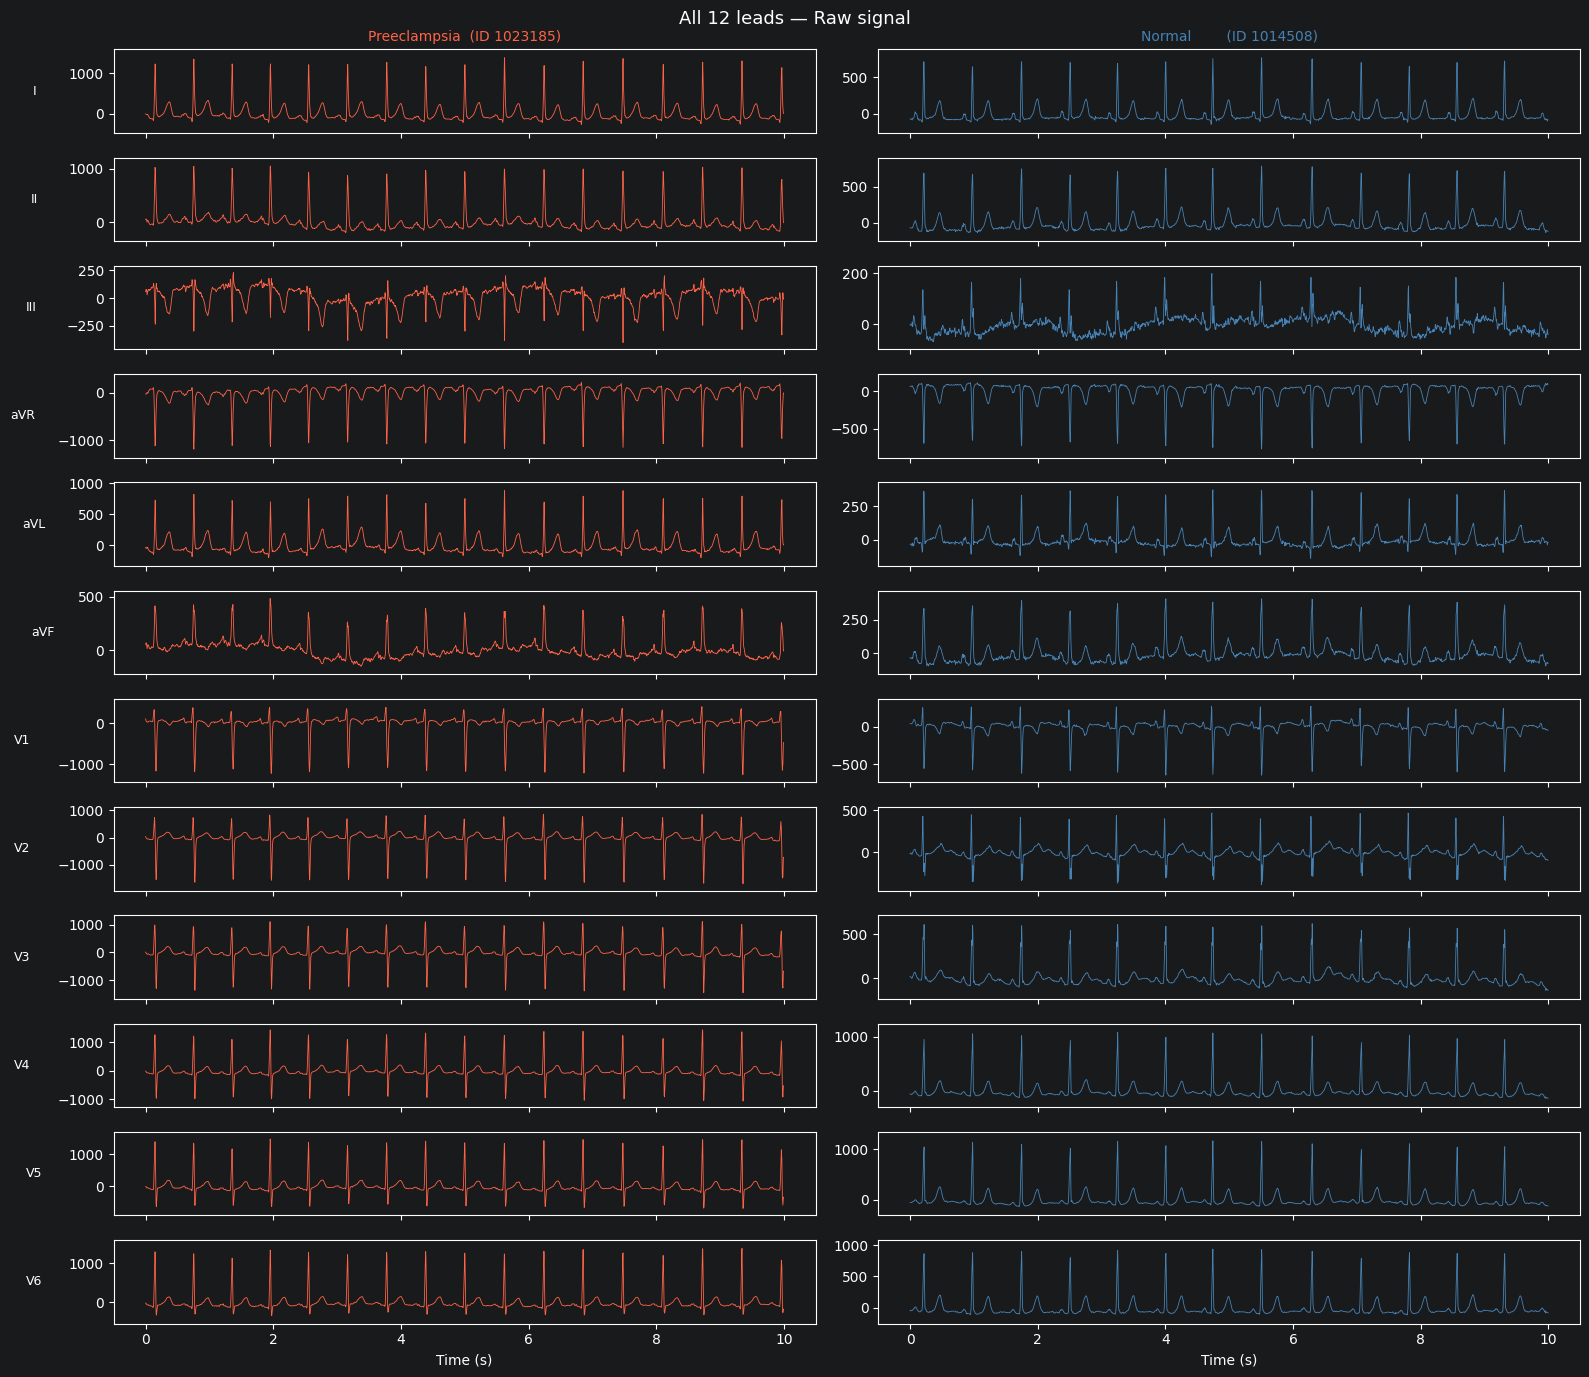

In [92]:
# Fixed samples used in every subsequent plot for consistency
VIS_POS = np.where(y == 1)[0][0]   # first preeclampsia
VIS_NEG = np.where(y == 0)[0][0]   # first normal
VIS_LEADS = LEAD_ORDER              # all 12

fig, axes = plt.subplots(12, 2, figsize=(16, 14), sharex=True, sharey=False)
fig.suptitle("All 12 leads — Raw signal", fontsize=13)
axes[0, 0].set_title(f"Preeclampsia  (ID {ids[VIS_POS]})", fontsize=10, color="tomato")
axes[0, 1].set_title(f"Normal        (ID {ids[VIS_NEG]})", fontsize=10, color="steelblue")

for i, lead in enumerate(VIS_LEADS):
    for col, (idx, color) in enumerate([(VIS_POS, "tomato"), (VIS_NEG, "steelblue")]):
        sig = X[idx, i]
        ax = axes[i, col]
        ax.plot(t, sig, lw=0.6, color=color)
        pad = max(abs(sig.max()), abs(sig.min())) * 0.15 or 1
        ax.set_ylim(sig.min() - pad, sig.max() + pad)
        if col == 0:
            ax.set_ylabel(lead, fontsize=9, rotation=0, labelpad=25, va="center")

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## 4. Progressive pipeline stages

In [93]:
import sys
sys.path.insert(0, "..")

from src.preprocessing.filters import BaselineWanderFilter
from src.preprocessing.normalization import ZScoreNormalization
from src.preprocessing.base import PreprocessingPipeline

# BWF params: cutoff=0.67 Hz (vs default 0.5), order=6 (vs default 4)
# Higher cutoff -> more low-freq drift removed; higher order -> steeper rolloff
BWF_CUTOFF = 0.5    # Hz
BWF_ORDER  = 4

# Stage snapshots — keep X_raw unmodified
X_raw = X.copy()

X_bwf = X_raw.copy()
X_bwf, _ = BaselineWanderFilter(cutoff=BWF_CUTOFF, order=BWF_ORDER, fs=FS).transform(X_bwf)

X_norm = X_bwf.copy()
X_norm, _ = ZScoreNormalization(per_lead=True).transform(X_norm)

print(f"BWF: cutoff={BWF_CUTOFF} Hz, order={BWF_ORDER}")
print("Stage shapes (all must match):")
print(f"  raw  : {X_raw.shape}")
print(f"  +BWF : {X_bwf.shape}")
print(f"  +norm: {X_norm.shape}")
print("\nZ-score check on X_norm - mean~0, std~1 per lead (first sample, first 3 leads):")
print(f"  mean: {X_norm[0].mean(axis=1)[:3].round(3)}")
print(f"  std : {X_norm[0].std(axis=1)[:3].round(3)}")

BWF: cutoff=0.5 Hz, order=4
Stage shapes (all must match):
  raw  : (92, 12, 2500)
  +BWF : (92, 12, 2500)
  +norm: (92, 12, 2500)

Z-score check on X_norm - mean~0, std~1 per lead (first sample, first 3 leads):
  mean: [ 0. -0. -0.]
  std : [1. 1. 1.]


## 5. Pipeline stages — Lead II comparison

| Stage | What happens |
|---|---|
| **Raw** | ADC counts straight off disk — may have slow drift and varying amplitude scale |
| **+ Baseline Wander Filter** | 4th-order zero-phase high-pass Butterworth at 0.5 Hz removes respiratory/motion drift below 0.5 Hz |
| **+ Z-score Norm** | Each lead independently shifted to mean=0, std=1 — removes inter-lead amplitude differences |

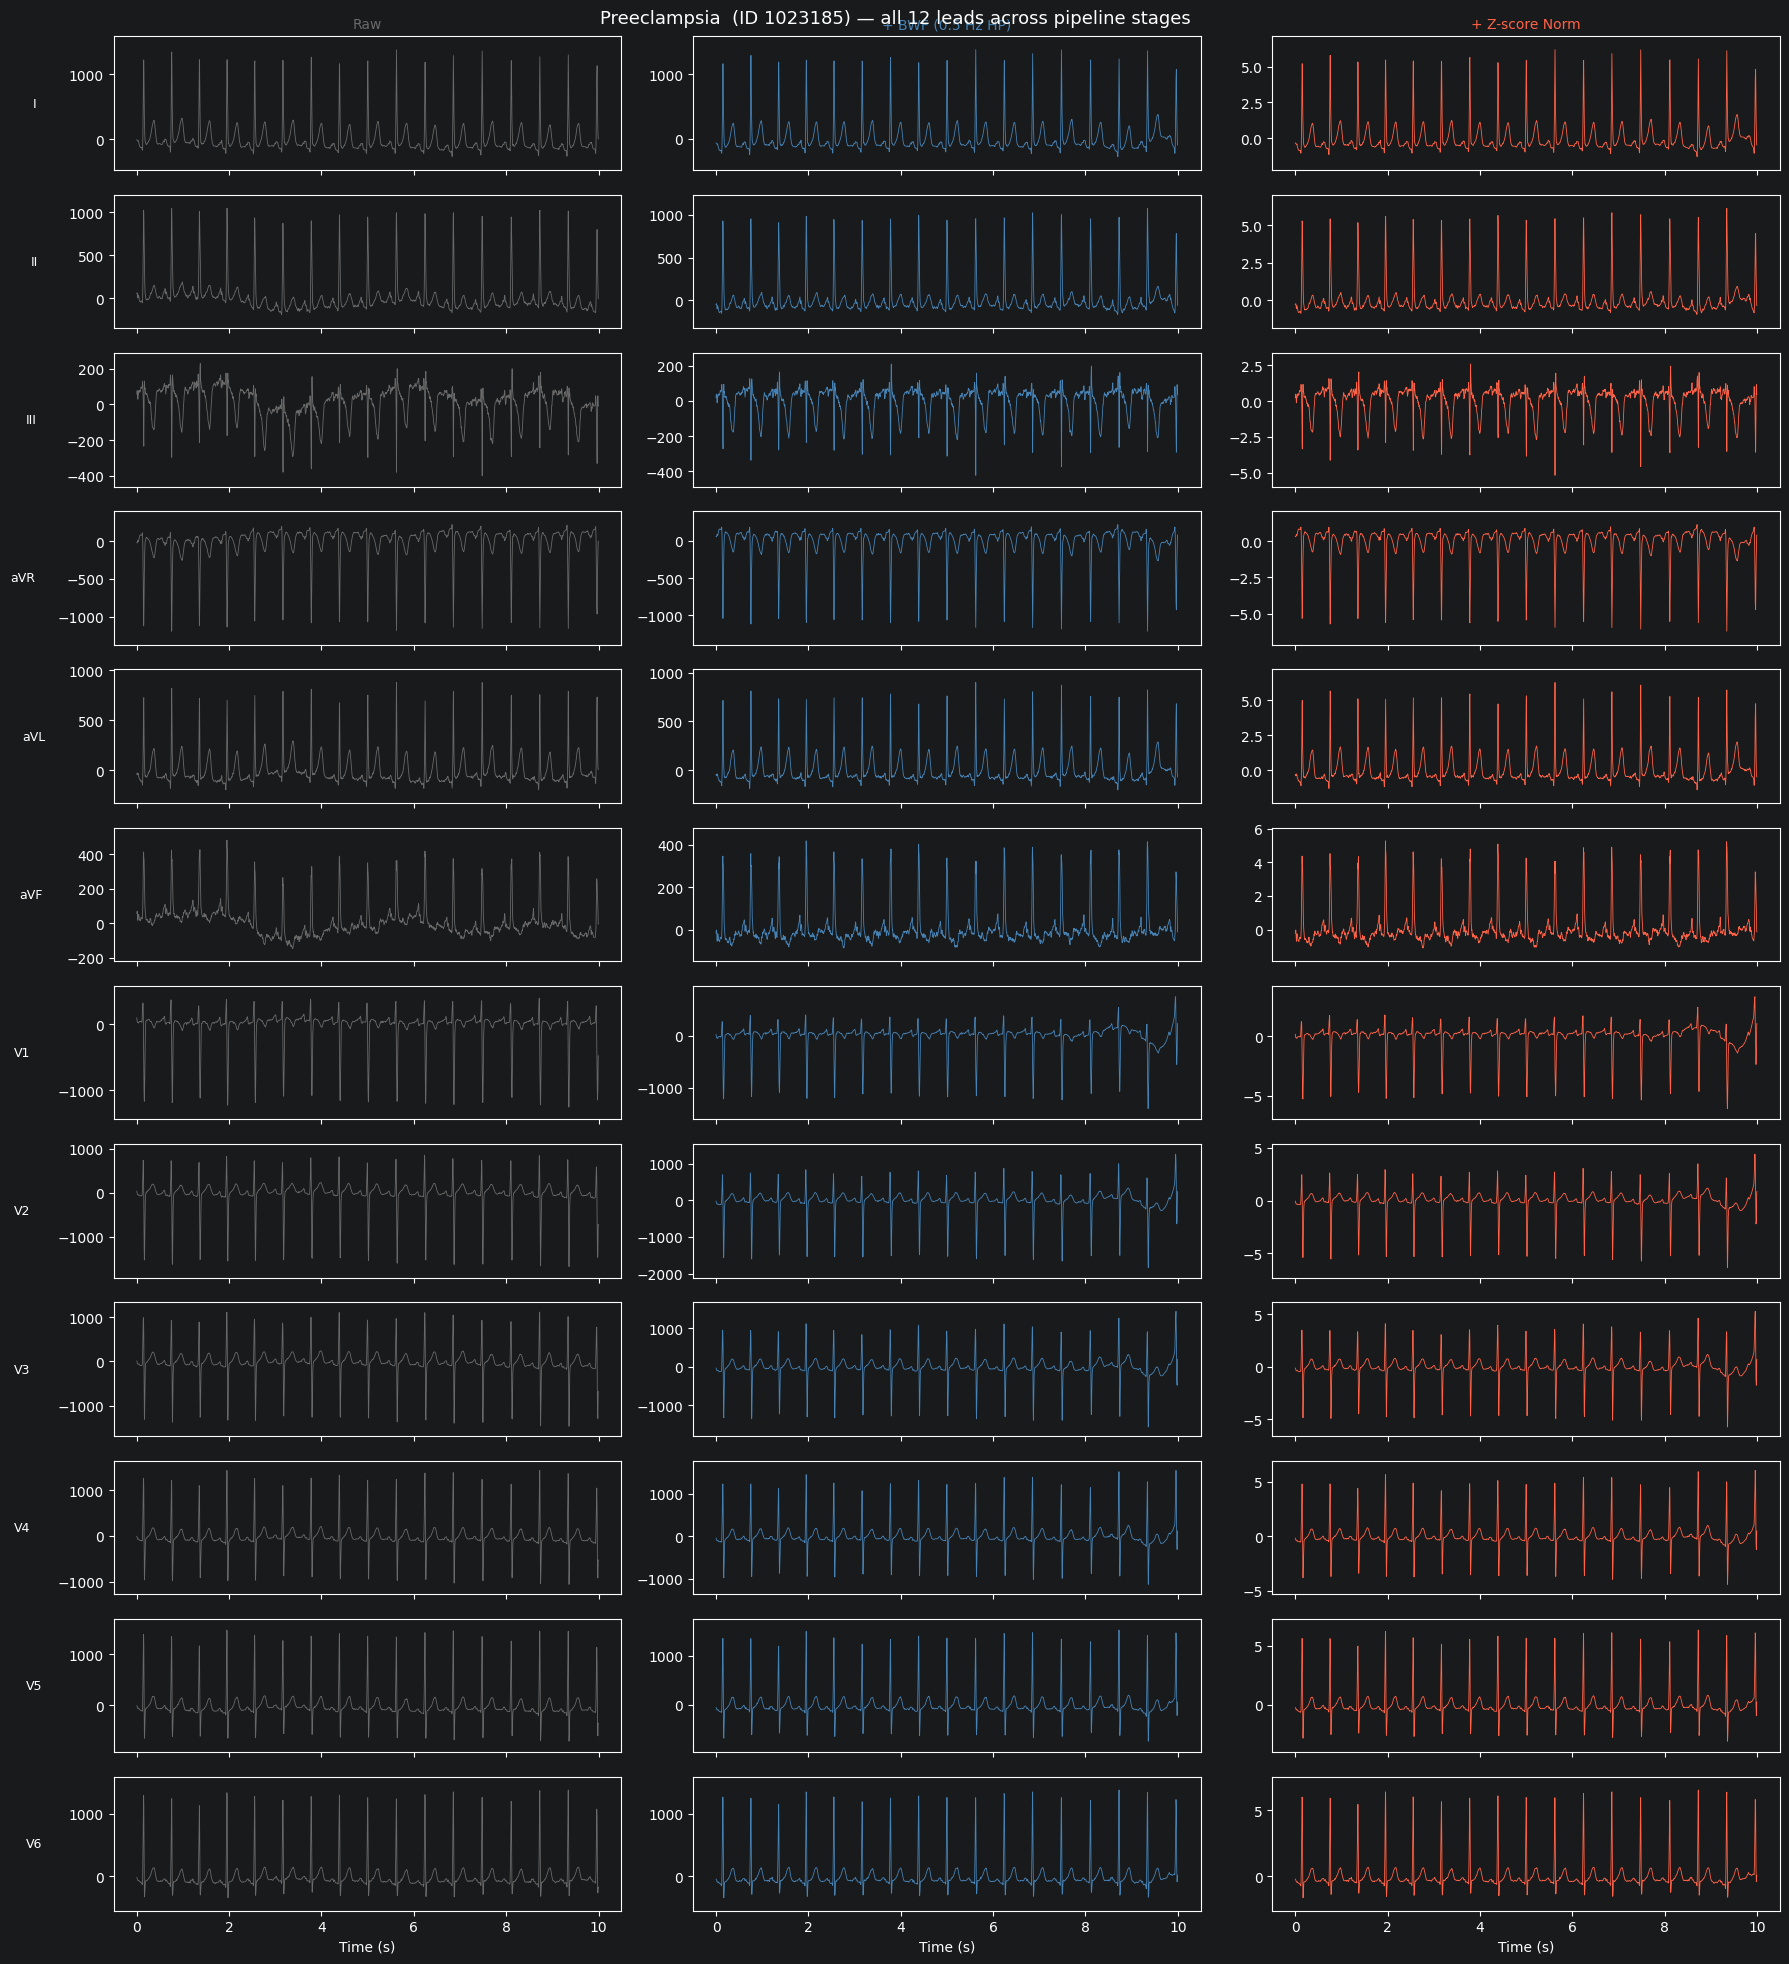

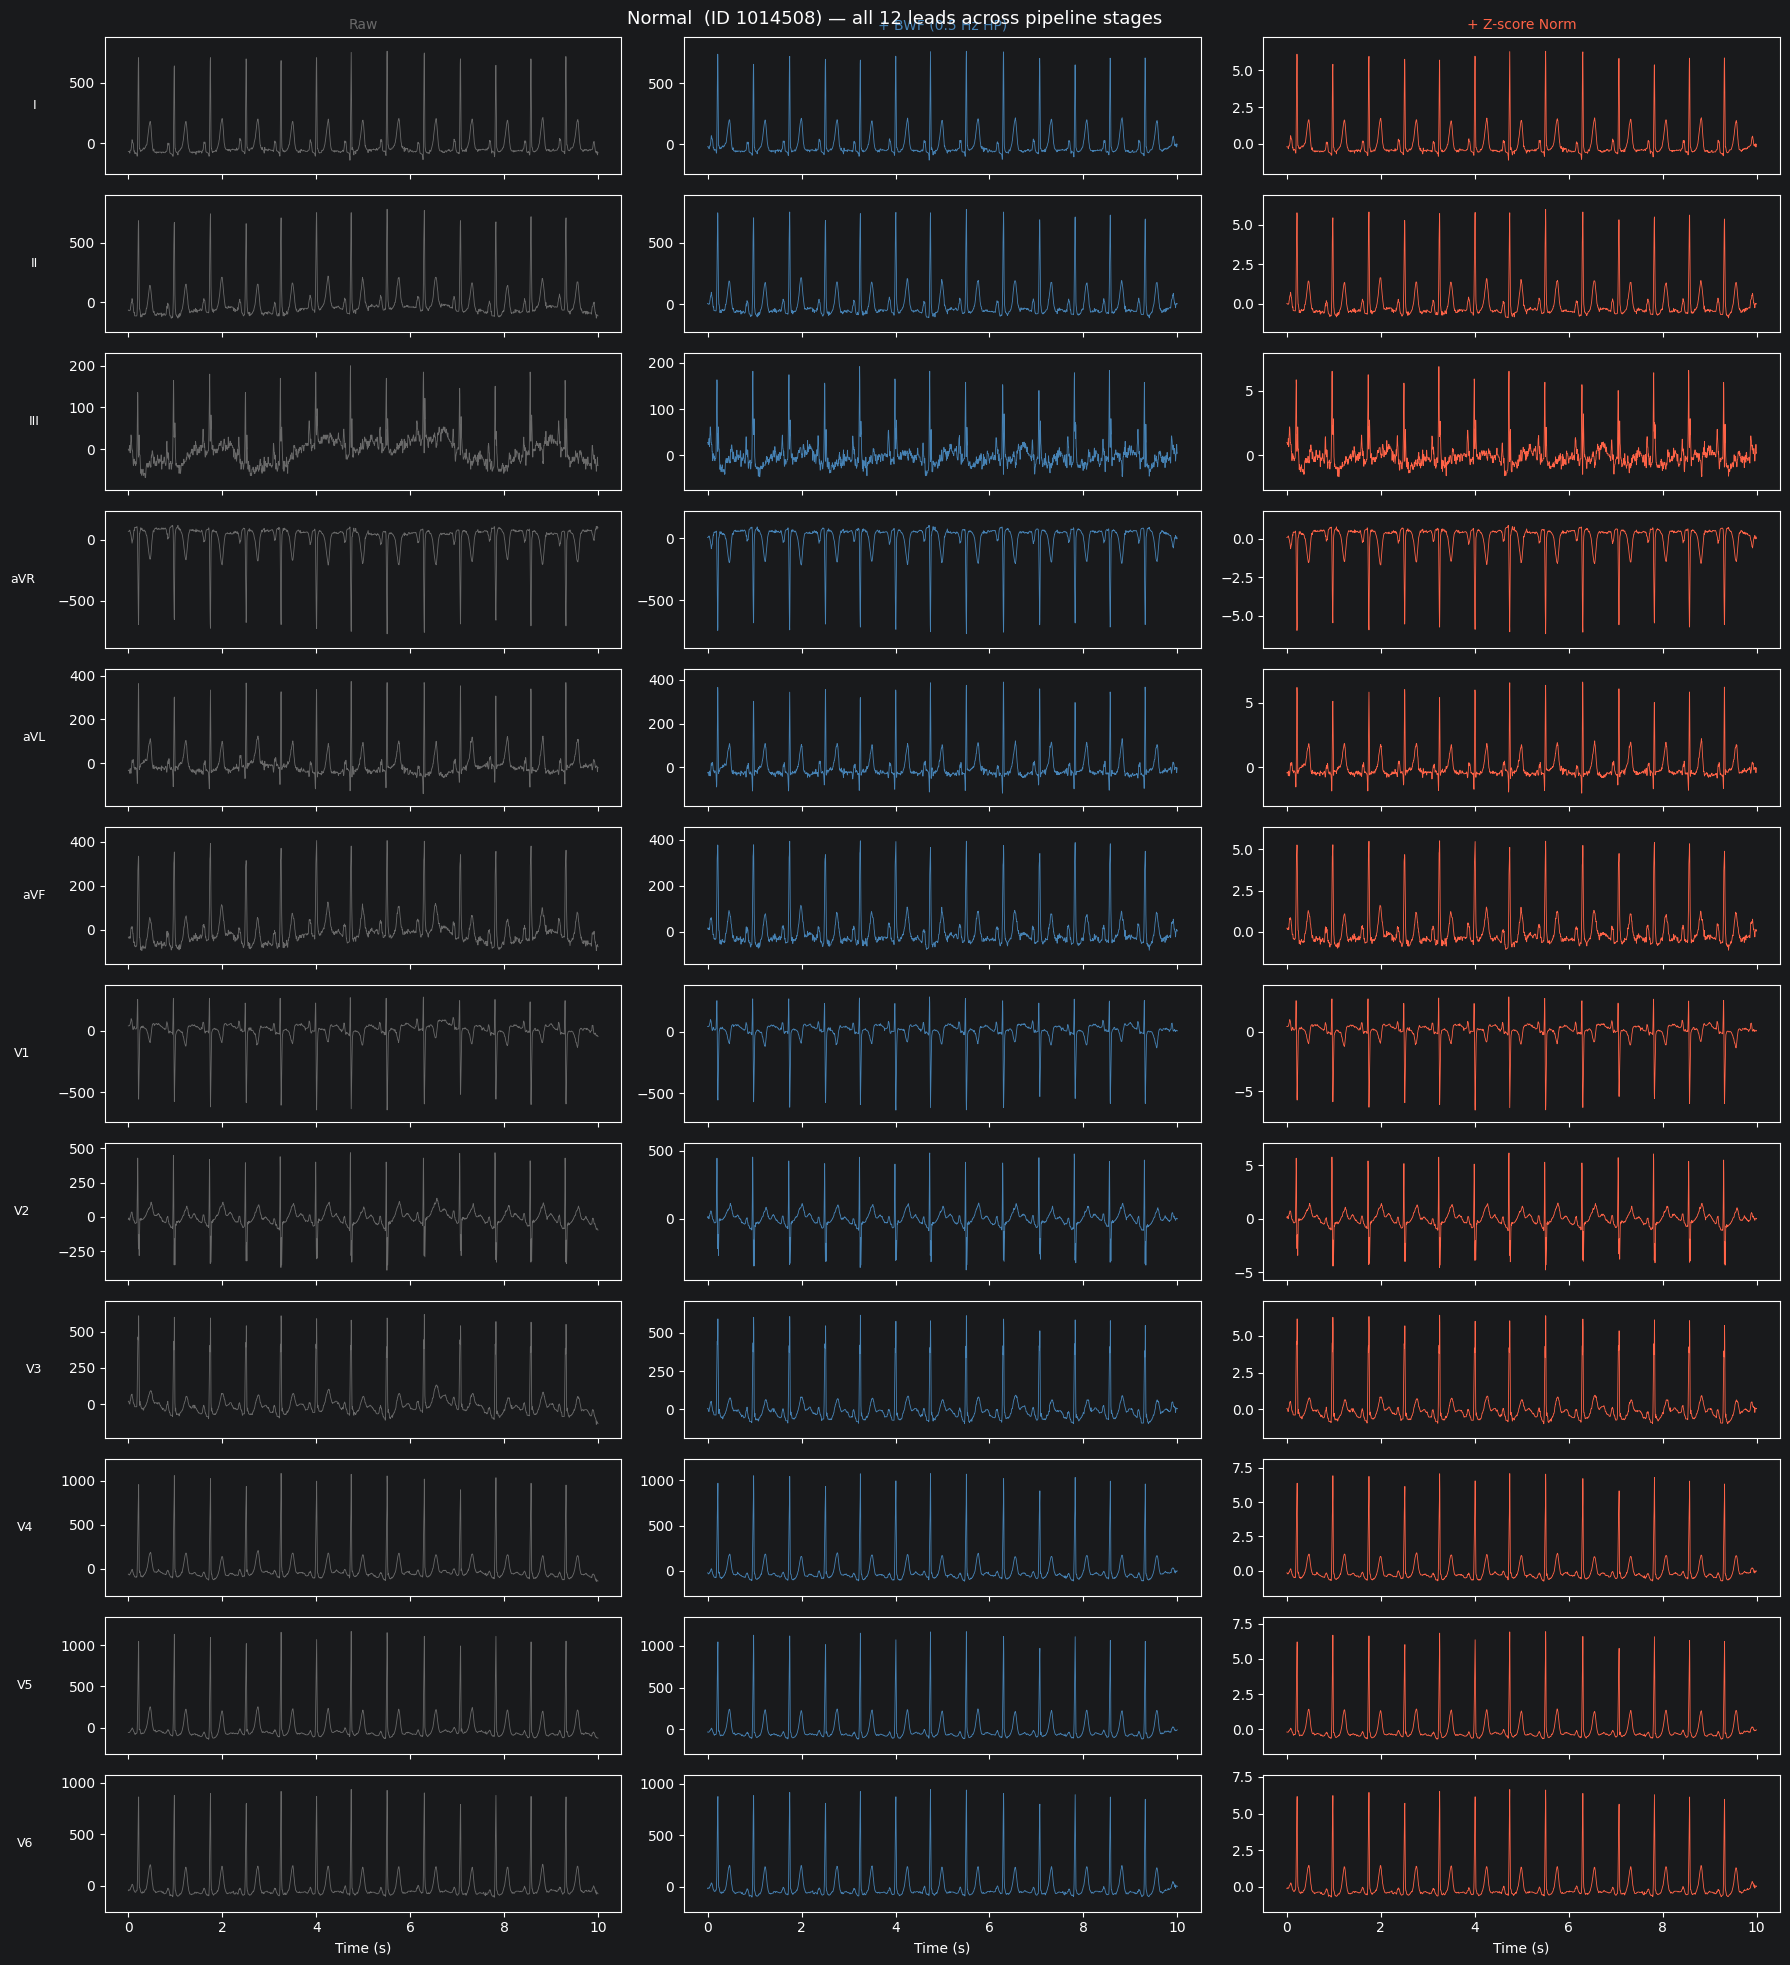

In [94]:
LEAD_VIS = "II"
li = LEAD_ORDER.index(LEAD_VIS)
stages = [
    ("Raw", X_raw,  "dimgray"),
    ("+ BWF (0.5 Hz HP)", X_bwf,  "steelblue"),
    ("+ Z-score Norm", X_norm, "tomato"),
]
show = [("Preeclampsia", VIS_POS), ("Normal", VIS_NEG)]

for class_lbl, idx in show:
    fig, axes = plt.subplots(12, 3, figsize=(18, 20), sharex=True)
    fig.suptitle(f"{class_lbl}  (ID {ids[idx]}) — all 12 leads across pipeline stages", fontsize=13)

    for col, (stage_name, X_stage, color) in enumerate(stages):
        axes[0, col].set_title(stage_name, fontsize=10, color=color)
        for row, lead in enumerate(LEAD_ORDER):
            sig = X_stage[idx, row]
            ax = axes[row, col]
            ax.plot(t, sig, lw=0.6, color=color)
            pad = max(abs(sig.max()), abs(sig.min())) * 0.15 or 0.1
            ax.set_ylim(sig.min() - pad, sig.max() + pad)
            if col == 0:
                ax.set_ylabel(lead, fontsize=9, rotation=0, labelpad=25, va="center")
            if row == 11:
                ax.set_xlabel("Time (s)")

    plt.tight_layout()
    plt.show()

## 6. All 12 leads — post-pipeline

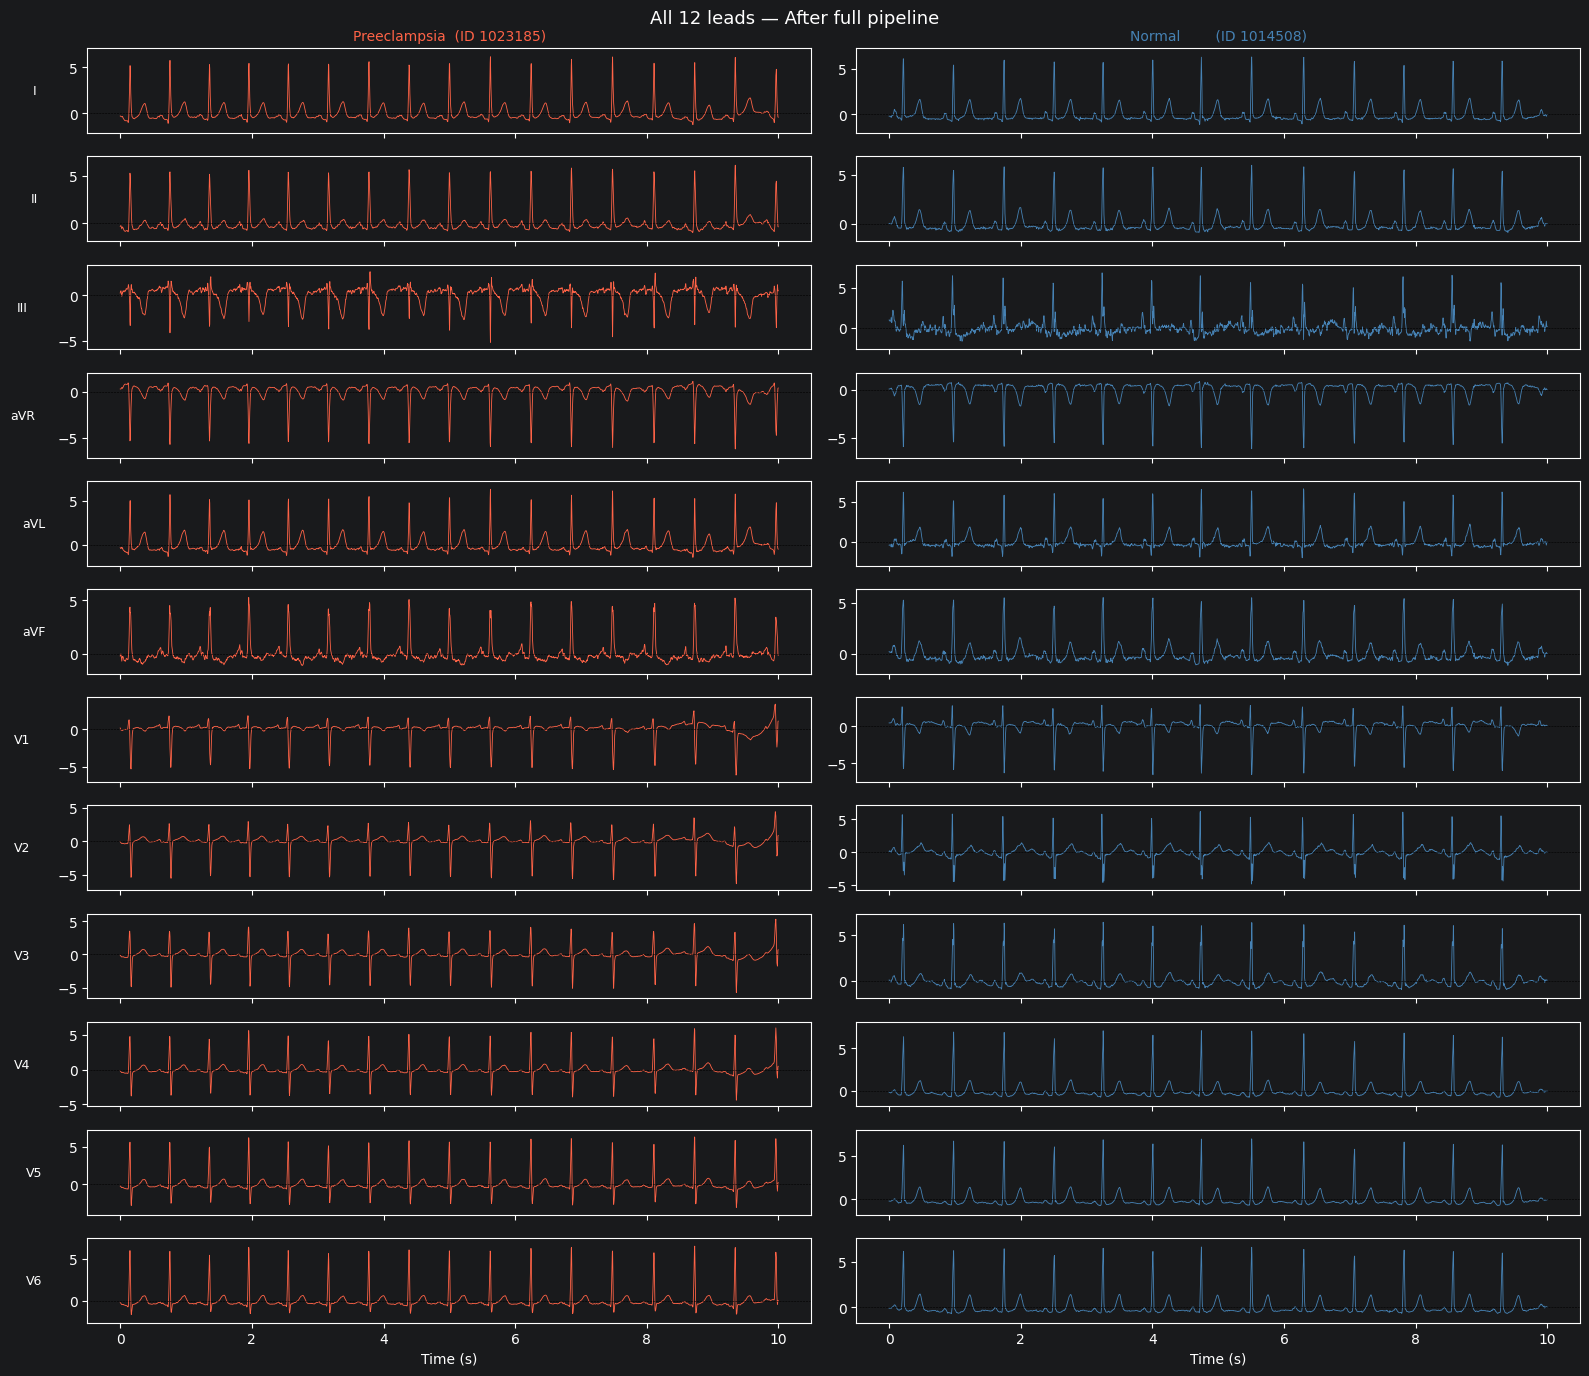

In [95]:
fig, axes = plt.subplots(12, 2, figsize=(16, 14), sharex=True, sharey=False)
fig.suptitle("All 12 leads — After full pipeline", fontsize=13)
axes[0, 0].set_title(f"Preeclampsia  (ID {ids[VIS_POS]})", fontsize=10, color="tomato")
axes[0, 1].set_title(f"Normal        (ID {ids[VIS_NEG]})", fontsize=10, color="steelblue")

for i, lead in enumerate(LEAD_ORDER):
    for col, (idx, color) in enumerate([(VIS_POS, "tomato"), (VIS_NEG, "steelblue")]):
        sig = X_norm[idx, i]
        ax = axes[i, col]
        ax.plot(t, sig, lw=0.6, color=color)
        ax.axhline(0, lw=0.4, color="k", linestyle="--")
        pad = max(abs(sig.max()), abs(sig.min())) * 0.15 or 0.1
        ax.set_ylim(sig.min() - pad, sig.max() + pad)
        if col == 0:
            ax.set_ylabel(lead, fontsize=9, rotation=0, labelpad=25, va="center")

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()